# Final Model V2.4 - Cross-Attention Fusion (Spatial-Temporal)

- **Base**: `Final_env_v2_3.ipynb` (Gated Fusion Success)
- **Improvement**: **Cross-Attention Fusion**
- **Concept**:
    - GRU provides the **Intent** (Query) -> "Player turning left"
    - CNN provides the **Spatial Map** (Key/Value) -> "Open space at (x,y)"
    - **Cross-Attention**: The model dynamically attends to specific spatial regions based on the player's movement intent.
- **Preprocessor**: `Preprocessing_final_v2` (Pure Physics, No Angle)

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from sklearn.model_selection import GroupKFold
import cv2 
from tqdm import tqdm
import joblib
import json

# [Same Preprocessor as V2.3]
from Preprocessing_final_v2_fixed import FootballPreprocessorMultimodal

FOLD_SEEDS = {
    1: 42, 2: 43, 3: 44, 4: 45, 5: 46,
    6: 47, 7: 48, 8: 49, 9: 50, 10: 51,
}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 1. 데이터 로드 및 전처리 (V2.3 동일)

In [2]:
DATA_DIR = './data'
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(f"Loaded {len(train_df)} rows")

Loaded 356721 rows


In [3]:
# Dataset Code - Identical to V2.3
class MultiModalDataset(Dataset):
    def __init__(self, episodes, img_size=(68, 105), augment=False, cache_images=True):
        self.episodes = episodes
        self.H, self.W = img_size
        self.augment = augment
        self.cache_images = cache_images
        self.img_cache = None
        
        if self.cache_images:
            print(f"Pre-rendering {len(episodes)} images (Cache Enabled)...")
            self.img_cache = [self._generate_image(ep['cont']) for ep in tqdm(episodes, desc="Caching Images")]

    def __len__(self):
        return len(self.episodes)

    def _generate_image(self, cont_data):
        img_np = np.zeros((2, self.H, self.W), dtype=np.float32)
        if len(cont_data) == 0:
             return torch.tensor(img_np, dtype=torch.float32)

        seq_len = cont_data.shape[0]
        xs = cont_data[:, 0]
        ys = cont_data[:, 1]
        
        x_idxs = (xs * (self.W - 1)).round().astype(int).clip(0, self.W - 1)
        y_idxs = (ys * (self.H - 1)).round().astype(int).clip(0, self.H - 1)
        
        for t in range(seq_len):
            px, py = x_idxs[t], y_idxs[t]
            img_np[0, py, px] = 1.0
            decay_val = (t + 1) / seq_len
            if t > 0:
                prev_px, prev_py = x_idxs[t-1], y_idxs[t-1]
                cv2.line(img_np[1], (prev_px, prev_py), (px, py), color=decay_val, thickness=1)
            else:
                img_np[1, py, px] = decay_val
        return torch.tensor(img_np, dtype=torch.float32)

    def __getitem__(self, idx):
        data = self.episodes[idx]
        cont = data['cont'].copy()
        target = data['target'].copy()
        
        if self.augment and random.random() < 0.5:
            cont[:, 1] = 1.0 - cont[:, 1] # start_y
            cont[:, 3] = 1.0 - cont[:, 3] # end_y_prev
            cont[:, 5] = -cont[:, 5]      # dy_prev
            target[1] = 1.0 - target[1]
            if self.cache_images:
                base_img = self.img_cache[idx]
                img = torch.flip(base_img, [1])
            else:
                img = self._generate_image(cont)
        else:
            if self.cache_images:
                img = self.img_cache[idx]
            else:
                img = self._generate_image(cont)
        
        cont_tensor = torch.tensor(cont, dtype=torch.float32)
        cat_tensor = torch.tensor(data['cat'], dtype=torch.long)
        target_tensor = torch.tensor(target, dtype=torch.float32)
        
        seq_len = cont.shape[0]
        aux_target = np.zeros((seq_len, 2), dtype=np.float32)
        if seq_len > 1:
            aux_target[:-1] = cont[1:, 0:2]
        aux_target[-1] = target
        aux_target_tensor = torch.tensor(aux_target, dtype=torch.float32)
        
        return img, cont_tensor, cat_tensor, target_tensor, aux_target_tensor

## 2. 모델 아키텍처 (Cross-Attention Fusion)
- **SpatialCNN**: `(128, 17, 26)` Map 반환
- **CrossAttention**: GRU Query -> CNN Map
- **GatedFusion**: GRU + Attended Context 결합

In [4]:
# [Helper] Self-Attention for CNN Refining
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv(x_cat)
        return self.sigmoid(x_out)

# [Modified] SpatialCNN (Retains Spatial Dimensions)
class SpatialCNN(nn.Module):
    def __init__(self):
        super(SpatialCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.sa = SpatialAttention()
        # No Pooling, No FC. Returns Feature Map directly.
        
    def forward(self, x):
        x = self.features(x)
        sa_map = self.sa(x)
        return x * sa_map # Shape: [B, 128, H/4, W/4]

class LSTMAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(LSTMAttention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)
    def forward(self, rnn_output):
        attn_weights = torch.softmax(self.attention(rnn_output), dim=1)
        return torch.sum(attn_weights * rnn_output, dim=1)

# [New] Cross Attention Module
class CrossAttention(nn.Module):
    def __init__(self, query_dim, key_dim, hidden_dim):
        super().__init__()
        self.query_proj = nn.Linear(query_dim, hidden_dim)
        self.key_proj = nn.Linear(key_dim, hidden_dim)
        self.value_proj = nn.Linear(key_dim, hidden_dim)
        self.scale = torch.sqrt(torch.tensor(hidden_dim, dtype=torch.float32))
        
    def forward(self, query, key_map):
        # query: [B, Q_Dim] (GRU State)
        # key_map: [B, K_Dim, H, W] (CNN Feature Map)
        
        B, C, H, W = key_map.shape
        # Flatten Key/Value: [B, H*W, C]
        flat_keys = key_map.view(B, C, -1).permute(0, 2, 1) 
        
        Q = self.query_proj(query).unsqueeze(1) # [B, 1, H_dim]
        K = self.key_proj(flat_keys)            # [B, H*W, H_dim]
        V = self.value_proj(flat_keys)          # [B, H*W, H_dim]
        
        # Attention Scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale.to(query.device) # [B, 1, H*W]
        attn_weights = F.softmax(scores, dim=-1)
        
        # Context Vector
        context = torch.bmm(attn_weights, V) # [B, 1, H_dim]
        return context.squeeze(1)

# [Recycle] Gated Fusion (Same as V2.3)
class GatedFusion(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.Sigmoid()
        )
    def forward(self, feat1, feat2):
        concat = torch.cat([feat1, feat2], dim=1)
        z = self.gate_net(concat)
        fused = z * feat1 + (1 - z) * feat2
        return fused

class MultiModalNetV8(nn.Module):
    def __init__(self, input_dim_cont, num_types, num_results, gru_hidden=96):
        super(MultiModalNetV8, self).__init__()
        # 1. Spatial CNN
        self.cnn = SpatialCNN() # Output: [B, 128, H, W]
        
        # 2. Sequential Embeddings
        self.type_emb = nn.Embedding(num_types, 8)
        self.result_emb = nn.Embedding(num_results, 8)
        total_input_dim = input_dim_cont + 8 + 8
        
        # 3. GRU (Split)
        self.gru_hidden = gru_hidden
        self.gru_fwd = nn.GRU(total_input_dim, gru_hidden, 2, batch_first=True, dropout=0.1)
        self.gru_bwd = nn.GRU(total_input_dim, gru_hidden, 2, batch_first=True, dropout=0.1)
        self.gru_attn = LSTMAttention(gru_hidden * 2)
        self.gru_fc = nn.Linear(gru_hidden * 2, 128)
        
        self.aux_fc = nn.Linear(gru_hidden, 2) 
        
        # 4. [NEW] Cross Attention
        # Query: GRU (128), Key: CNN (128)
        self.cross_attn = CrossAttention(query_dim=128, key_dim=128, hidden_dim=128)
        
        # 5. [Recycle] Gated Fusion
        # Fuse (Original GRU) + (Context-Aware Spatial Feature)
        self.gated_fusion = GatedFusion(dim=128)
        
        # 6. Final Head
        self.final_fc = nn.Sequential(
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, img, cont, cat, lengths):
        # CNN (Spatial Map)
        cnn_map = self.cnn(img) # [B, 128, 17, 26]
        
        # Embeddings
        emb_type = self.type_emb(cat[:, :, 0])
        emb_result = self.result_emb(cat[:, :, 1])
        x_seq = torch.cat([cont, emb_type, emb_result], dim=2)
        
        # GRU Forward/Backward
        packed_fwd = pack_padded_sequence(x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_fwd_packed, _ = self.gru_fwd(packed_fwd)
        out_fwd, _ = pad_packed_sequence(out_fwd_packed, batch_first=True)
        
        x_seq_bwd = x_seq.clone()
        for i, length in enumerate(lengths):
            x_seq_bwd[i, :length] = x_seq[i, :length].flip(0)
        packed_bwd = pack_padded_sequence(x_seq_bwd, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_bwd_packed, _ = self.gru_bwd(packed_bwd)
        out_bwd, _ = pad_packed_sequence(out_bwd_packed, batch_first=True)
        for i, length in enumerate(lengths):
            out_bwd[i, :length] = out_bwd[i, :length].flip(0)
            
        # GRU Feature
        gru_out_combined = torch.cat([out_fwd, out_bwd], dim=2)
        gru_ctx = self.gru_attn(gru_out_combined)
        seq_feat = F.relu(self.gru_fc(gru_ctx)) # [B, 128] (Intent)
        
        # [Cross-Attention Step]
        # Query: seq_feat (Intent)
        # Key/Value: cnn_map (Opportunity)
        context_feat = self.cross_attn(seq_feat, cnn_map) # [B, 128] (Relevant Space)
        
        # [Fusion Step]
        # Fuse Intent + Opportunity
        fused = self.gated_fusion(seq_feat, context_feat)
        
        final_out = self.final_fc(fused)
        aux_out = self.aux_fc(out_fwd)
        
        return final_out, aux_out

# Losses (Same)
class EuclideanLoss(nn.Module):
    def __init__(self):
        super(EuclideanLoss, self).__init__()
    def forward(self, pred, target):
        pred_real = pred * torch.tensor([105.0, 68.0], device=pred.device)
        target_real = target * torch.tensor([105.0, 68.0], device=target.device)
        return torch.mean(torch.sqrt(torch.sum((pred_real - target_real)**2, dim=1) + 1e-6))
        
class MaskedSeqEuclideanLoss(nn.Module):
    def __init__(self):
        super(MaskedSeqEuclideanLoss, self).__init__()
    def forward(self, pred, target, lengths):
        mask = torch.arange(pred.size(1), device=pred.device)[None, :] < lengths[:, None]
        mask = mask.unsqueeze(-1)
        pred_real = pred * torch.tensor([105.0, 68.0], device=pred.device)
        target_real = target * torch.tensor([105.0, 68.0], device=target.device)
        diff = pred_real - target_real
        dist = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-6)
        dist = dist * mask.squeeze(-1)
        return dist.sum() / mask.sum()

## 3. 학습
- Models and Preprocessors saved in `models_final_v2_4/`

In [5]:
def multimodal_collate_fn(batch):
    imgs, conts, cats, targets, aux_targets = zip(*batch)
    imgs_batched = torch.stack(imgs, dim=0)
    lengths = torch.tensor([len(c) for c in conts], dtype=torch.long)
    conts_padded = pad_sequence(conts, batch_first=True)
    cats_padded = pad_sequence(cats, batch_first=True)
    targets = torch.stack(targets, dim=0)
    aux_targets_padded = pad_sequence(aux_targets, batch_first=True)
    return imgs_batched, conts_padded, cats_padded, lengths, targets, aux_targets_padded

def train_multimodal_v2_4(train_df, n_splits=10, epochs=100, batch_size=64, lr=0.001):
    gkf = GroupKFold(n_splits=n_splits)
    groups = train_df['game_id'] 
    
    fold_scores = []

    input_dim_cont = None
    num_types = None
    num_results = None
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df, groups=groups)):
        fold_seed = FOLD_SEEDS[(fold % 10) + 1]
        seed_everything(fold_seed)
        print(f"[Fold {fold+1}] Seed fixed to {fold_seed}")
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        train_sub_df = train_df.iloc[train_idx].copy()
        val_sub_df = train_df.iloc[val_idx].copy()
        
        preprocessor = FootballPreprocessorMultimodal()
        preprocessor.fit(train_sub_df)

        if input_dim_cont is None:
            input_dim_cont = preprocessor.get_input_dim()
            num_types, num_results = preprocessor.get_num_classes()
            print(f"Model Dimensions: input={input_dim_cont}, types={num_types}, results={num_results}")
        
        train_episodes = preprocessor.transform(train_sub_df, is_train=True)
        val_episodes = preprocessor.transform(val_sub_df, is_train=True)
        
        train_dataset = MultiModalDataset(train_episodes, augment=True, cache_images=True)
        val_dataset = MultiModalDataset(val_episodes, augment=False, cache_images=True)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=multimodal_collate_fn, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=multimodal_collate_fn)
        
        # [V2.4 Model]
        model = MultiModalNetV8(input_dim_cont, num_types, num_results).to(DEVICE)
        
        criterion_main = EuclideanLoss()
        criterion_aux = MaskedSeqEuclideanLoss() 
        
        optimizer = optim.Adam(model.parameters(), lr=lr) 
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
        best_dist = float('inf')
        best_state = None
        patience_counter = 0
        patience_limit = 15
        
        if not os.path.exists('models_final_v2_4'):
            os.makedirs('models_final_v2_4')
            
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for batch in train_loader:
                imgs, cont, cat, lengths, target, aux_target = batch
                imgs, cont, cat, lengths, target, aux_target = imgs.to(DEVICE), cont.to(DEVICE), cat.to(DEVICE), lengths.to(DEVICE), target.to(DEVICE), aux_target.to(DEVICE)
                
                optimizer.zero_grad()
                pred, aux_pred = model(imgs, cont, cat, lengths)
                
                loss_m = criterion_main(pred, target)
                loss_a = criterion_aux(aux_pred, aux_target, lengths)
                
                loss = loss_m + 0.5 * loss_a
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            train_loss /= len(train_loader)
            
            model.eval()
            val_dists = []
            with torch.no_grad():
                for batch in val_loader:
                    imgs, cont, cat, lengths, target, aux_target = batch
                    imgs, cont, cat, lengths, target, aux_target = imgs.to(DEVICE), cont.to(DEVICE), cat.to(DEVICE), lengths.to(DEVICE), target.to(DEVICE), aux_target.to(DEVICE)
                    
                    pred, _ = model(imgs, cont, cat, lengths)
                    
                    pred_real = pred.cpu().numpy() * np.array([105.0, 68.0])
                    target_real = target.cpu().numpy() * np.array([105.0, 68.0])
                    val_dists.extend(np.sqrt(np.sum((pred_real - target_real)**2, axis=1)))
            
            mean_dist = np.mean(val_dists)
            scheduler.step(mean_dist)
            print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Val Dist {mean_dist:.4f}")
            
            if mean_dist < best_dist:
                best_dist = mean_dist
                best_state = model.state_dict()
                torch.save(best_state, f"models_final_v2_4/multimodal_v2_4_{fold+1}.pth")
                joblib.dump(preprocessor, f"models_final_v2_4/preprocessor_v2_4_{fold+1}.pkl")
                print(f"  -> Saved Best Model (Dist: {best_dist:.4f})")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience_limit:
                    print("Early Stopping")
                    break
        
        print(f"Fold {fold+1} Finished. Best Valid Dist: {best_dist:.4f}")
        fold_scores.append(best_dist)
    
    with open('scores_v2_4.json', 'w') as f:
        json.dump(fold_scores, f)
        
    print(f"Average Score: {np.mean(fold_scores):.4f}")

train_multimodal_v2_4(train_df)

[Fold 1] Seed fixed to 42

=== Fold 1/10 ===
Model Dimensions: input=10, types=27, results=21
Pre-rendering 13827 images (Cache Enabled)...


Caching Images: 100%|██████████| 13827/13827 [00:00<00:00, 15913.00it/s]


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 17674.80it/s]


Epoch 1: Train Loss 67.5922, Val Dist 20.0213
  -> Saved Best Model (Dist: 20.0213)
Epoch 2: Train Loss 49.2152, Val Dist 17.6512
  -> Saved Best Model (Dist: 17.6512)
Epoch 3: Train Loss 46.4806, Val Dist 17.5744
  -> Saved Best Model (Dist: 17.5744)
Epoch 4: Train Loss 45.1491, Val Dist 16.1735
  -> Saved Best Model (Dist: 16.1735)
Epoch 5: Train Loss 44.4278, Val Dist 16.0723
  -> Saved Best Model (Dist: 16.0723)
Epoch 6: Train Loss 43.4642, Val Dist 16.2663
Epoch 7: Train Loss 42.8474, Val Dist 15.1465
  -> Saved Best Model (Dist: 15.1465)
Epoch 8: Train Loss 42.3665, Val Dist 15.2651
Epoch 9: Train Loss 42.0637, Val Dist 15.1049
  -> Saved Best Model (Dist: 15.1049)
Epoch 10: Train Loss 41.7423, Val Dist 15.1730
Epoch 11: Train Loss 41.3573, Val Dist 15.1699
Epoch 12: Train Loss 41.0650, Val Dist 14.7447
  -> Saved Best Model (Dist: 14.7447)
Epoch 13: Train Loss 40.9742, Val Dist 14.4118
  -> Saved Best Model (Dist: 14.4118)
Epoch 14: Train Loss 40.6838, Val Dist 14.3386
  -> Save

...

Epoch 1: Train Loss 66.4907, Val Dist 19.1200
  -> Saved Best Model (Dist: 19.1200)
Epoch 2: Train Loss 48.8982, Val Dist 17.5108
  -> Saved Best Model (Dist: 17.5108)
Epoch 3: Train Loss 46.4889, Val Dist 16.7086
  -> Saved Best Model (Dist: 16.7086)
Epoch 4: Train Loss 45.2339, Val Dist 16.6576
  -> Saved Best Model (Dist: 16.6576)
Epoch 5: Train Loss 43.9652, Val Dist 17.0164
Epoch 6: Train Loss 43.3344, Val Dist 16.6429
  -> Saved Best Model (Dist: 16.6429)
Epoch 7: Train Loss 42.6804, Val Dist 15.6511
  -> Saved Best Model (Dist: 15.6511)
Epoch 8: Train Loss 42.2027, Val Dist 15.4655
  -> Saved Best Model (Dist: 15.4655)
Epoch 9: Train Loss 41.8255, Val Dist 15.3531
  -> Saved Best Model (Dist: 15.3531)
Epoch 10: Train Loss 41.5819, Val Dist 15.6520
Epoch 11: Train Loss 41.2772, Val Dist 15.0439
  -> Saved Best Model (Dist: 15.0439)
Epoch 12: Train Loss 41.0907, Val Dist 14.8488
  -> Saved Best Model (Dist: 14.8488)
Epoch 13: Train Loss 40.6915, Val Dist 14.9241
Epoch 14: Train Lo

Caching Images: 100%|██████████| 13850/13850 [00:00<00:00, 14854.58it/s]


Pre-rendering 1578 images (Cache Enabled)...


Caching Images: 100%|██████████| 1578/1578 [00:00<00:00, 13864.42it/s]


Epoch 1: Train Loss 65.0167, Val Dist 20.4104
  -> Saved Best Model (Dist: 20.4104)
Epoch 2: Train Loss 49.1940, Val Dist 17.1019
  -> Saved Best Model (Dist: 17.1019)
Epoch 3: Train Loss 46.3951, Val Dist 16.4648
  -> Saved Best Model (Dist: 16.4648)
Epoch 4: Train Loss 45.3034, Val Dist 16.2010
  -> Saved Best Model (Dist: 16.2010)
Epoch 5: Train Loss 44.0738, Val Dist 15.2943
  -> Saved Best Model (Dist: 15.2943)
Epoch 6: Train Loss 43.3367, Val Dist 15.1729
  -> Saved Best Model (Dist: 15.1729)
Epoch 7: Train Loss 42.7738, Val Dist 16.0317
Epoch 8: Train Loss 42.2959, Val Dist 15.4504
Epoch 9: Train Loss 41.8664, Val Dist 14.9797
  -> Saved Best Model (Dist: 14.9797)
Epoch 10: Train Loss 41.5021, Val Dist 14.6082
  -> Saved Best Model (Dist: 14.6082)
Epoch 11: Train Loss 41.3164, Val Dist 14.8121
Epoch 12: Train Loss 41.1851, Val Dist 14.2519
  -> Saved Best Model (Dist: 14.2519)
Epoch 13: Train Loss 40.7288, Val Dist 14.2885
Epoch 14: Train Loss 40.5985, Val Dist 14.4477
Epoch 15:

In [6]:
# Inference V2.4
class TestMMDataset(Dataset):
    def __init__(self, sub_df, preprocessor, img_size=(68, 105)):
        self.sub_df = sub_df
        self.prep = preprocessor
        self.H, self.W = img_size
    def __len__(self): return len(self.sub_df)
    def _gen_img(self, cont):
        img = np.zeros((2, self.H, self.W), dtype=np.float32)
        if len(cont) == 0: return torch.tensor(img, dtype=torch.float32)
        xs, ys = cont[:,0], cont[:,1]
        xi = (xs*(self.W-1)).round().astype(int).clip(0, self.W-1)
        yi = (ys*(self.H-1)).round().astype(int).clip(0, self.H-1)
        for t in range(len(cont)):
            img[0, yi[t], xi[t]] = 1.0
            decay = (t+1)/len(cont)
            if t > 0:
                cv2.line(img[1], (xi[t-1], yi[t-1]), (xi[t], yi[t]), color=decay, thickness=1)
            else:
                img[1, yi[t], xi[t]] = decay
        return torch.tensor(img, dtype=torch.float32)
    def __getitem__(self, idx):
        path = self.sub_df.iloc[idx]['path']
        full_path = os.path.join("data", path[2:] if path.startswith("./") else path)
        try:
            df = pd.read_csv(full_path)
            eps = self.prep.transform(df, False)
        except: eps = []
        if not eps:
            d = self.prep.get_input_dim()
            c = torch.zeros((1,d), dtype=torch.float32)
            cat = torch.zeros((1,5), dtype=torch.long)
            img = torch.zeros((2, self.H, self.W), dtype=torch.float32)
        else:
            data = eps[0]
            c = torch.tensor(data['cont'], dtype=torch.float32)
            cat = torch.tensor(data['cat'], dtype=torch.long)
            img = self._gen_img(data['cont'])
        return img, c, cat

def test_collate(b):
    img, c, cat = zip(*b)
    ib = torch.stack(img)
    l = torch.tensor([len(x) for x in c], dtype=torch.long)
    cp = pad_sequence(c, batch_first=True)
    catp = pad_sequence(cat, batch_first=True)
    return ib, cp, catp, l

sub = pd.read_csv("data/sample_submission.csv")
tm = pd.read_csv("data/test.csv")
sub = sub.merge(tm, on="game_episode", how="left")

# Load Ref for dimensions
prep_ref = joblib.load('models_final_v2_4/preprocessor_v2_4_1.pkl')
GD = prep_ref.get_input_dim()
nT, nR = prep_ref.get_num_classes()

all_preds = []
for f in range(1, 11):
    try:
        prep = joblib.load(f'models_final_v2_4/preprocessor_v2_4_{f}.pkl')
        ds = TestMMDataset(sub, prep)
        dl = DataLoader(ds, 128, False, collate_fn=test_collate)
        model = MultiModalNetV8(GD, nT, nR).to(DEVICE)
        model.load_state_dict(torch.load(f'models_final_v2_4/multimodal_v2_4_{f}.pth', map_location=DEVICE))
        model.eval()
        fold_p = []
        with torch.no_grad():
            for b in tqdm(dl, desc=f'Fold {f}'):
                i, c, ct, l = [x.to(DEVICE) for x in b]
                p, _ = model(i, c, ct, l)
                pn = p.cpu().numpy()
                pn[:,0] *= 105; pn[:,1] *= 68
                fold_p.append(pn)
        all_preds.append(np.vstack(fold_p))
    except Exception as e: print(e)

if all_preds:
    avg = np.mean(all_preds, axis=0)
    sub['end_x'] = avg[:,0].clip(0, 105)
    sub['end_y'] = avg[:,1].clip(0, 68)
    sub[['game_episode','end_x','end_y']].to_csv('Final_env_v2_4.csv', index=False)
    print("Done: Final_env_v2_4.csv")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27812\1272777022.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'models_final

Done: Final_env_v2_4.csv


In [7]:
# === R² (결정 계수) 평가 ===
from sklearn.metrics import r2_score

def evaluate_r2(train_df, n_splits=10):
    """학습된 모델로 각 Fold의 Validation에서 R² 계산"""
    gkf = GroupKFold(n_splits=n_splits)
    groups = train_df['game_id']
    
    # [FIX] Fold 1 기준 차원 고정 (학습 시와 동일)
    prep_ref = joblib.load("models_final_v2_4/preprocessor_v2_4_1.pkl")
    GD = prep_ref.get_input_dim()
    nT, nR = prep_ref.get_num_classes()
    
    all_preds, all_targets = [], []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df, groups=groups)):
        fold_seed = FOLD_SEEDS[(fold % 10) + 1]
        seed_everything(fold_seed)
        
        val_sub_df = train_df.iloc[val_idx].copy()
        
        preprocessor = joblib.load(f"models_final_v2_4/preprocessor_v2_4_{fold+1}.pkl")
        val_episodes = preprocessor.transform(val_sub_df, is_train=True)
        val_dataset = MultiModalDataset(val_episodes, augment=False, cache_images=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=multimodal_collate_fn)
        
        # [FIX] 모든 Fold에서 동일한 차원(nT=27, nR=21)으로 모델 생성
        model = MultiModalNetV8(GD, nT, nR).to(DEVICE)
        model.load_state_dict(torch.load(f"models_final_v2_4/multimodal_v2_4_{fold+1}.pth", map_location=DEVICE, weights_only=True))
        model.eval()
        
        with torch.no_grad():
            for batch in val_loader:
                imgs, cont, cat, lengths, target, aux_target = batch
                imgs, cont, cat, lengths, target = imgs.to(DEVICE), cont.to(DEVICE), cat.to(DEVICE), lengths.to(DEVICE), target.to(DEVICE)
                pred, _ = model(imgs, cont, cat, lengths)
                
                pred_real = pred.cpu().numpy() * np.array([105.0, 68.0])
                target_real = target.cpu().numpy() * np.array([105.0, 68.0])
                all_preds.append(pred_real)
                all_targets.append(target_real)
        
        print(f"Fold {fold+1} loaded.")
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    r2_x = r2_score(all_targets[:, 0], all_preds[:, 0])
    r2_y = r2_score(all_targets[:, 1], all_preds[:, 1])
    r2_overall = r2_score(all_targets, all_preds)
    
    print(f"\n{'='*40}")
    print(f"R² Score (X):       {r2_x:.4f}")
    print(f"R² Score (Y):       {r2_y:.4f}")
    print(f"R² Score (Overall): {r2_overall:.4f}")
    print(f"{'='*40}")
    
    return r2_x, r2_y, r2_overall

r2_x, r2_y, r2_overall = evaluate_r2(train_df)


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 18655.90it/s]


Fold 1 loaded.
Pre-rendering 1489 images (Cache Enabled)...


Caching Images: 100%|██████████| 1489/1489 [00:00<00:00, 18201.29it/s]


Fold 2 loaded.
Pre-rendering 1550 images (Cache Enabled)...


...

Fold 8 loaded.
Pre-rendering 1622 images (Cache Enabled)...


Caching Images: 100%|██████████| 1622/1622 [00:00<00:00, 19454.95it/s]


Fold 9 loaded.
Pre-rendering 1578 images (Cache Enabled)...


Caching Images: 100%|██████████| 1578/1578 [00:00<00:00, 18912.21it/s]


Fold 10 loaded.

R² Score (X):       0.7546
R² Score (Y):       0.7126
R² Score (Overall): 0.7336


# 🔬 Ablation Study: 보조손실 / Cross-Attention 기여도

면접 대비용. **앞 셀(import, 데이터 로드, 모델 정의)을 먼저 실행한 뒤** 실행하세요.
시간 절약을 위해 **1-fold + 짧은 epoch**로 빠르게 비교합니다 (절대 성능이 아니라 *상대 비교*가 목적).

비교군:
1. **Full** — Cross-Attention + 보조손실 (현재 채택)
2. **No-Aux** — 보조손실 제거 (aux weight = 0)
3. **No-CrossAttn** — Cross-Attention 대신 단순 결합(seq_feat만 사용)


In [8]:
# === Ablation: Aux Loss / Cross-Attention ===
# 기존 정의 재사용: MultiModalNetV8, EuclideanLoss, MaskedSeqEuclideanLoss,
#   FootballPreprocessorMultimodal, MultiModalDataset, multimodal_collate_fn, seed_everything
import copy, numpy as np, torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

# --- No-CrossAttn 변형: cross-attention을 건너뛰고 seq_feat을 그대로 사용 ---
class MultiModalNet_NoCross(MultiModalNetV8):
    def forward(self, img, cont, cat, lengths):
        cnn_map = self.cnn(img)
        emb_type = self.type_emb(cat[:, :, 0]); emb_result = self.result_emb(cat[:, :, 1])
        x_seq = torch.cat([cont, emb_type, emb_result], dim=2)
        from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
        packed_fwd = pack_padded_sequence(x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_fwd_packed, _ = self.gru_fwd(packed_fwd)
        out_fwd, _ = pad_packed_sequence(out_fwd_packed, batch_first=True)
        x_seq_bwd = x_seq.clone()
        for i, length in enumerate(lengths):
            x_seq_bwd[i, :length] = x_seq[i, :length].flip(0)
        packed_bwd = pack_padded_sequence(x_seq_bwd, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_bwd_packed, _ = self.gru_bwd(packed_bwd)
        out_bwd, _ = pad_packed_sequence(out_bwd_packed, batch_first=True)
        for i, length in enumerate(lengths):
            out_bwd[i, :length] = out_bwd[i, :length].flip(0)
        gru_out_combined = torch.cat([out_fwd, out_bwd], dim=2)
        gru_ctx = self.gru_attn(gru_out_combined)
        seq_feat = torch.relu(self.gru_fc(gru_ctx))
        # Cross-Attention 생략: context 없이 seq_feat 자기 자신을 융합 입력으로
        fused = self.gated_fusion(seq_feat, seq_feat)
        final_out = self.final_fc(fused)
        aux_out = self.aux_fc(out_fwd)
        return final_out, aux_out

def train_one_fold(model_cls, aux_weight=0.5, epochs=20, batch_size=64, lr=1e-3, seed=42):
    seed_everything(seed)
    gkf = GroupKFold(n_splits=10)
    tr_idx, va_idx = next(gkf.split(train_df, groups=train_df['game_id']))
    tr_df, va_df = train_df.iloc[tr_idx].copy(), train_df.iloc[va_idx].copy()
    pre = FootballPreprocessorMultimodal(); pre.fit(tr_df)
    in_dim = pre.get_input_dim(); n_types, n_results = pre.get_num_classes()
    tr_ep = pre.transform(tr_df, is_train=True); va_ep = pre.transform(va_df, is_train=True)
    tr_ds = MultiModalDataset(tr_ep, augment=True, cache_images=True)
    va_ds = MultiModalDataset(va_ep, augment=False, cache_images=True)
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, collate_fn=multimodal_collate_fn, drop_last=True)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False, collate_fn=multimodal_collate_fn)
    model = model_cls(in_dim, n_types, n_results).to(DEVICE)
    crit_m, crit_a = EuclideanLoss(), MaskedSeqEuclideanLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    best = float('inf')
    for ep in range(epochs):
        model.train()
        for batch in tr_ld:
            imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
            opt.zero_grad()
            pred, aux_pred = model(imgs, cont, cat, lengths)
            loss = crit_m(pred, target) + aux_weight * crit_a(aux_pred, aux_t, lengths)
            loss.backward(); opt.step()
        model.eval(); dists=[]
        with torch.no_grad():
            for batch in va_ld:
                imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
                pred,_ = model(imgs, cont, cat, lengths)
                pr = pred.cpu().numpy()*np.array([105.,68.]); tg = target.cpu().numpy()*np.array([105.,68.])
                dists.extend(np.sqrt(np.sum((pr-tg)**2, axis=1)))
        md = float(np.mean(dists)); best = min(best, md)
    return best

print('Running ablation (1-fold, 20 epochs each)...')
res = {}
res['Full (CrossAttn + Aux)']   = train_one_fold(MultiModalNetV8, aux_weight=0.5)
res['No-Aux (aux_w=0)']         = train_one_fold(MultiModalNetV8, aux_weight=0.0)
res['No-CrossAttn']             = train_one_fold(MultiModalNet_NoCross, aux_weight=0.5)

import pandas as pd
df = pd.DataFrame([{'variant':k, 'val_dist(m)':round(v,3)} for k,v in res.items()])
print('\n========== Ablation (lower = better) ==========')
print(df.to_string(index=False))
base = res['Full (CrossAttn + Aux)']
print('\n기여도 (Full 대비 오차 증가량):')
for k,v in res.items():
    if k!='Full (CrossAttn + Aux)':
        print(f'  - {k} 제거 시: {v-base:+.3f} m')


Running ablation (1-fold, 20 epochs each)...
Pre-rendering 13827 images (Cache Enabled)...


Caching Images: 100%|██████████| 13827/13827 [00:00<00:00, 18561.56it/s]


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 18596.18it/s]


Pre-rendering 13827 images (Cache Enabled)...


...

Pre-rendering 13827 images (Cache Enabled)...


Caching Images: 100%|██████████| 13827/13827 [00:00<00:00, 16992.53it/s]


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 18852.37it/s]



========== Ablation (lower = better) ==========
               variant  val_dist(m)
Full (CrossAttn + Aux)       14.173
      No-Aux (aux_w=0)       14.269
          No-CrossAttn       14.914

기여도 (Full 대비 오차 증가량):
  - No-Aux (aux_w=0) 제거 시: +0.096 m
  - No-CrossAttn 제거 시: +0.741 m


# 🔬🔬 Modality Ablation: 멀티모달 vs 시계열만 vs 이미지만

'좌표를 이미지로 변환한 것'이 실제로 성능에 기여하는지 검증합니다.
**앞 셀(모델 정의, train_df 등)을 먼저 실행**한 뒤 돌리세요. 1-fold 빠른 비교입니다.

- **Multimodal (Full)** — 현재 구조 (CNN + GRU + Cross-Attention)
- **Seq-only** — 이미지 경로 제거, GRU(시계열)만으로 좌표 예측
- **Img-only** — GRU 경로 제거, CNN(이미지)만으로 좌표 예측 (보조손실 없음)


In [9]:
# === Modality Ablation ===
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

# --- (A) Seq-only: GRU만 사용, CNN/Cross-Attn 제거 ---
class SeqOnlyNet(MultiModalNetV8):
    def forward(self, img, cont, cat, lengths):
        emb_type = self.type_emb(cat[:, :, 0]); emb_result = self.result_emb(cat[:, :, 1])
        x_seq = torch.cat([cont, emb_type, emb_result], dim=2)
        packed_fwd = pack_padded_sequence(x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_fwd_packed, _ = self.gru_fwd(packed_fwd)
        out_fwd, _ = pad_packed_sequence(out_fwd_packed, batch_first=True)
        x_seq_bwd = x_seq.clone()
        for i, length in enumerate(lengths):
            x_seq_bwd[i, :length] = x_seq[i, :length].flip(0)
        packed_bwd = pack_padded_sequence(x_seq_bwd, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_bwd_packed, _ = self.gru_bwd(packed_bwd)
        out_bwd, _ = pad_packed_sequence(out_bwd_packed, batch_first=True)
        for i, length in enumerate(lengths):
            out_bwd[i, :length] = out_bwd[i, :length].flip(0)
        gru_out_combined = torch.cat([out_fwd, out_bwd], dim=2)
        gru_ctx = self.gru_attn(gru_out_combined)
        seq_feat = F.relu(self.gru_fc(gru_ctx))
        final_out = self.final_fc(seq_feat)   # Cross-Attn/Fusion 없이 바로 예측
        aux_out = self.aux_fc(out_fwd)
        return final_out, aux_out

# --- (B) Img-only: CNN만 사용, GRU 경로 제거 (보조손실 없음) ---
class ImgOnlyNet(nn.Module):
    def __init__(self, input_dim_cont, num_types, num_results, gru_hidden=96):
        super().__init__()
        self.cnn = SpatialCNN()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 2))
    def forward(self, img, cont, cat, lengths):
        cnn_map = self.cnn(img)                # [B,128,H,W]
        final_out = self.head(cnn_map)         # GAP -> 좌표
        aux_out = None                         # 보조손실 없음
        return final_out, aux_out

def train_modality(model_cls, use_aux=True, epochs=20, batch_size=64, lr=1e-3, seed=42):
    seed_everything(seed)
    gkf = GroupKFold(n_splits=10)
    tr_idx, va_idx = next(gkf.split(train_df, groups=train_df['game_id']))
    tr_df, va_df = train_df.iloc[tr_idx].copy(), train_df.iloc[va_idx].copy()
    pre = FootballPreprocessorMultimodal(); pre.fit(tr_df)
    in_dim = pre.get_input_dim(); n_types, n_results = pre.get_num_classes()
    tr_ep = pre.transform(tr_df, is_train=True); va_ep = pre.transform(va_df, is_train=True)
    tr_ds = MultiModalDataset(tr_ep, augment=True, cache_images=True)
    va_ds = MultiModalDataset(va_ep, augment=False, cache_images=True)
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, collate_fn=multimodal_collate_fn, drop_last=True)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False, collate_fn=multimodal_collate_fn)
    model = model_cls(in_dim, n_types, n_results).to(DEVICE)
    crit_m, crit_a = EuclideanLoss(), MaskedSeqEuclideanLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    best = float('inf')
    for ep in range(epochs):
        model.train()
        for batch in tr_ld:
            imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
            opt.zero_grad()
            pred, aux_pred = model(imgs, cont, cat, lengths)
            loss = crit_m(pred, target)
            if use_aux and (aux_pred is not None):
                loss = loss + 0.5 * crit_a(aux_pred, aux_t, lengths)
            loss.backward(); opt.step()
        model.eval(); dists=[]
        with torch.no_grad():
            for batch in va_ld:
                imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
                pred,_ = model(imgs, cont, cat, lengths)
                pr = pred.cpu().numpy()*np.array([105.,68.]); tg = target.cpu().numpy()*np.array([105.,68.])
                dists.extend(np.sqrt(np.sum((pr-tg)**2, axis=1)))
        best = min(best, float(np.mean(dists)))
    n_params = sum(p.numel() for p in model.parameters())
    return best, n_params

print('Running modality ablation (1-fold, 20 epochs)...')
res = {}
res['Multimodal (Full)'] = train_modality(MultiModalNetV8, use_aux=True)
res['Seq-only (GRU)']    = train_modality(SeqOnlyNet,      use_aux=True)
res['Img-only (CNN)']    = train_modality(ImgOnlyNet,      use_aux=False)

import pandas as pd
rows = [{'modality':k, 'val_dist(m)':round(v[0],3), 'params':f'{v[1]/1000:.0f}K'} for k,v in res.items()]
df = pd.DataFrame(rows)
print('\n========== Modality Ablation (lower dist = better) ==========')
print(df.to_string(index=False))
base = res['Multimodal (Full)'][0]
print('\nFull 대비 오차 증가량 (단일 modality로 갈 때 손해):')
for k,v in res.items():
    if k!='Multimodal (Full)':
        print(f'  - {k}: {v[0]-base:+.3f} m')
print('\n→ 면접 포인트: 이미지/시계열 각각 단독보다 멀티모달이 낮으면,')
print('   이미지 변환 도입이 실제 성능 기여를 했다는 정량적 근거가 됨.')


Running modality ablation (1-fold, 20 epochs)...
Pre-rendering 13827 images (Cache Enabled)...


Caching Images: 100%|██████████| 13827/13827 [00:00<00:00, 16684.29it/s]


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 16084.83it/s]


Pre-rendering 13827 images (Cache Enabled)...


...

Pre-rendering 13827 images (Cache Enabled)...


Caching Images: 100%|██████████| 13827/13827 [00:00<00:00, 16969.79it/s]


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 19018.96it/s]



========== Modality Ablation (lower dist = better) ==========
         modality  val_dist(m) params
Multimodal (Full)       14.173   393K
   Seq-only (GRU)       14.835   393K
   Img-only (CNN)       21.262   102K

Full 대비 오차 증가량 (단일 modality로 갈 때 손해):
  - Seq-only (GRU): +0.662 m
  - Img-only (CNN): +7.088 m

→ 면접 포인트: 이미지/시계열 각각 단독보다 멀티모달이 낮으면,
   이미지 변환 도입이 실제 성능 기여를 했다는 정량적 근거가 됨.


## 🎯 Cross-Attention 공간 히트맵 시각화

K리그의 Cross-Attention은 **시계열 의도(Query)가 경기장 feature map의
어느 공간 위치(Key/Value)에 주목했는지**를 학습합니다.
그 attention weight를 경기장 위에 히트맵으로 그리면, 모델이 패스 좌표를
예측할 때 **경기장의 어느 영역을 봤는지** 시각적으로 보여줄 수 있습니다.

**(앞에서 학습한 `MultiModalNetV8` 모델 인스턴스 `viz_model`이 필요 — 아래 셀이 없으면 새로 1-fold 학습)**

viz_model 없음 -> 1-fold 학습 (시드 42)
Pre-rendering 13827 images (Cache Enabled)...


Caching Images: 100%|██████████| 13827/13827 [00:00<00:00, 16496.14it/s]


Pre-rendering 1601 images (Cache Enabled)...


Caching Images: 100%|██████████| 1601/1601 [00:00<00:00, 16934.23it/s]


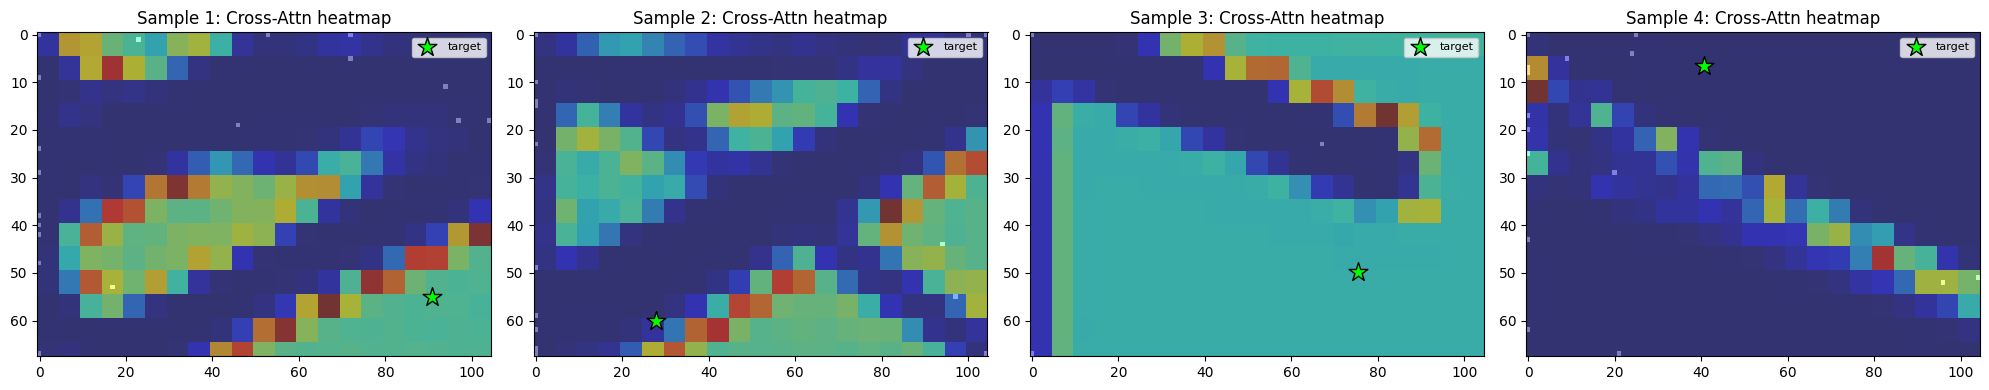


해석 가이드:
 - 빨강/노랑이 진한 영역 = 모델이 패스 좌표 예측 시 주목한 경기장 위치
 - 초록 별(target)과 주목 영역의 관계를 보면, 시계열 의도가 공간의
   어디를 참조해 좌표를 추론했는지 정성적으로 확인 가능


In [10]:
# === K리그: Cross-Attention 공간 히트맵 ===
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

# CrossAttention에서 attention weight를 함께 반환하도록 monkey-patch
_orig_forward = CrossAttention.forward
def _forward_with_weights(self, query, key_map):
    B, C, H, W = key_map.shape
    flat_keys = key_map.view(B, C, -1).permute(0, 2, 1)
    Q = self.query_proj(query).unsqueeze(1)
    K = self.key_proj(flat_keys)
    V = self.value_proj(flat_keys)
    scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale.to(query.device)
    attn_weights = F.softmax(scores, dim=-1)      # [B,1,H*W]
    context = torch.bmm(attn_weights, V).squeeze(1)
    self.last_attn = attn_weights.detach().cpu()  # 저장
    self.last_hw = (H, W)
    return context
CrossAttention.forward = _forward_with_weights

# 학습된 모델 확보
try:
    _ = viz_model; print('using existing viz_model')
except NameError:
    print('viz_model 없음 -> 1-fold 학습 (시드 42)')
    seed_everything(42)
    gkf = GroupKFold(n_splits=10)
    tr_idx, va_idx = next(gkf.split(train_df, groups=train_df['game_id']))
    tr_df = train_df.iloc[tr_idx].copy(); va_df = train_df.iloc[va_idx].copy()
    pre = FootballPreprocessorMultimodal(); pre.fit(tr_df)
    in_dim = pre.get_input_dim(); n_types, n_results = pre.get_num_classes()
    tr_ep = pre.transform(tr_df, is_train=True); va_ep = pre.transform(va_df, is_train=True)
    tr_ds = MultiModalDataset(tr_ep, augment=True, cache_images=True)
    va_ds = MultiModalDataset(va_ep, augment=False, cache_images=True)
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True, collate_fn=multimodal_collate_fn, drop_last=True)
    import torch.optim as optim
    viz_model = MultiModalNetV8(in_dim, n_types, n_results).to(DEVICE)
    crit_m, crit_a = EuclideanLoss(), MaskedSeqEuclideanLoss()
    opt = optim.Adam(viz_model.parameters(), lr=1e-3)
    for ep in range(20):
        viz_model.train()
        for batch in tr_ld:
            imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
            opt.zero_grad()
            pred, aux_pred = viz_model(imgs, cont, cat, lengths)
            loss = crit_m(pred, target) + 0.5*crit_a(aux_pred, aux_t, lengths)
            loss.backward(); opt.step()
    # 시각화용 validation 로더
    va_ld = DataLoader(va_ds, batch_size=8, shuffle=False, collate_fn=multimodal_collate_fn)

# 시각화용 배치 하나 가져오기
try:
    va_ld
except NameError:
    gkf = GroupKFold(n_splits=10)
    tr_idx, va_idx = next(gkf.split(train_df, groups=train_df['game_id']))
    va_df = train_df.iloc[va_idx].copy()
    pre = FootballPreprocessorMultimodal(); pre.fit(train_df.iloc[tr_idx])
    va_ep = pre.transform(va_df, is_train=True)
    va_ds = MultiModalDataset(va_ep, augment=False, cache_images=True)
    va_ld = DataLoader(va_ds, batch_size=8, shuffle=False, collate_fn=multimodal_collate_fn)

viz_model.eval()
batch = next(iter(va_ld))
imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
with torch.no_grad():
    pred, _ = viz_model(imgs, cont, cat, lengths)

attn = viz_model.cross_attn.last_attn      # [B,1,H*W]
H, W = viz_model.cross_attn.last_hw
attn_maps = attn.squeeze(1).view(-1, H, W).numpy()   # [B,H,W]

# 샘플 4개 히트맵 (경기장 위에)
n_show = min(4, attn_maps.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 4))
if n_show == 1: axes=[axes]
for i in range(n_show):
    # 입력 이미지(2채널 중 궤적 채널)와 attention 겹쳐보기
    base = imgs[i,0].cpu().numpy()      # 첫 채널(궤적)
    am = attn_maps[i]
    am_resized = np.kron(am, np.ones((base.shape[0]//H+1, base.shape[1]//W+1)))[:base.shape[0], :base.shape[1]]
    axes[i].imshow(base, cmap='gray', alpha=0.6, aspect='auto')
    axes[i].imshow(am_resized, cmap='jet', alpha=0.5, aspect='auto')
    px, py = pred[i].cpu().numpy()*np.array([W, H])  # 예측좌표(대략 위치 표시용)
    tx, ty = target[i].cpu().numpy()*np.array([base.shape[1], base.shape[0]])
    axes[i].scatter([tx],[ty], c='lime', marker='*', s=200, edgecolors='k', label='target')
    axes[i].set_title(f'Sample {i+1}: Cross-Attn heatmap')
    axes[i].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

print('\n해석 가이드:')
print(' - 빨강/노랑이 진한 영역 = 모델이 패스 좌표 예측 시 주목한 경기장 위치')
print(' - 초록 별(target)과 주목 영역의 관계를 보면, 시계열 의도가 공간의')
print('   어디를 참조해 좌표를 추론했는지 정성적으로 확인 가능')

# 원복 (다른 셀에 영향 없게)
CrossAttention.forward = _orig_forward


## 🎯 GatedFusion 게이트값 시각화 (시계열 vs 공간 의존도)

Cross-Attention이 '공간의 어디를 볼지'를 정했다면, **GatedFusion은
그렇게 얻은 공간 참조 결과(context_feat)와 원래 시계열 의도(seq_feat)를
최종적으로 얼마나씩 반영할지**를 sigmoid 게이트 `z`로 정합니다.
`fused = z * seq_feat + (1-z) * context_feat`

→ z가 1에 가까우면 **시계열 의도**, 0에 가까우면 **공간(Cross-Attn) 정보**에 의존.
**(앞 히트맵 셀에서 학습한 `viz_model` 재사용)**

GatedFusion z (=seq_feat weight): mean=0.675, std=0.034
1에 가까울수록 시계열 의도, 0에 가까울수록 공간(Cross-Attn) 정보에 의존



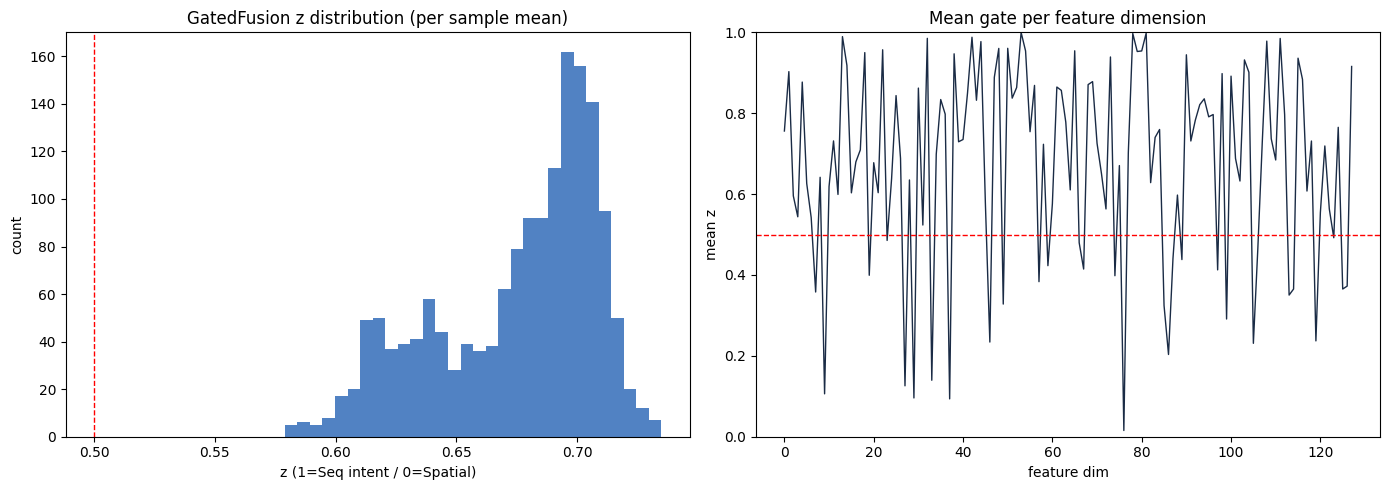


해석 가이드:
 - 전체 평균이 0.5보다 크면 최종 융합에서 시계열 의도를 더 신뢰,
   작으면 Cross-Attention으로 얻은 공간 정보를 더 신뢰한다는 의미
 - Cross-Attn(공간 어디를 볼지) + GatedFusion(그 공간을 얼마나 믿을지)이
   두 단계로 작동함을 함께 설명할 수 있음


In [11]:
# === K리그: GatedFusion 게이트값(z) 추출 & 시각화 ===
import numpy as np, torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import GroupKFold

# GatedFusion이 z를 저장하도록 patch
_orig_gf = GatedFusion.forward
def _gf_with_z(self, feat1, feat2):
    concat = torch.cat([feat1, feat2], dim=1)
    z = self.gate_net(concat)
    self.last_z = z.detach().cpu()    # [B, dim]
    return z * feat1 + (1 - z) * feat2
GatedFusion.forward = _gf_with_z

# viz_model 필요 (앞 히트맵 셀에서 만들어짐). 없으면 안내.
try:
    _ = viz_model
except NameError:
    raise RuntimeError('viz_model이 없습니다. 위의 Cross-Attention 히트맵 셀을 먼저 실행하세요.')

# validation 배치로 z 수집
try:
    va_ld
except NameError:
    gkf = GroupKFold(n_splits=10)
    tr_idx, va_idx = next(gkf.split(train_df, groups=train_df['game_id']))
    pre = FootballPreprocessorMultimodal(); pre.fit(train_df.iloc[tr_idx])
    va_ep = pre.transform(train_df.iloc[va_idx].copy(), is_train=True)
    va_ds = MultiModalDataset(va_ep, augment=False, cache_images=True)
    va_ld = DataLoader(va_ds, batch_size=64, shuffle=False, collate_fn=multimodal_collate_fn)

viz_model.eval()
all_z = []
with torch.no_grad():
    for batch in va_ld:
        imgs, cont, cat, lengths, target, aux_t = [b.to(DEVICE) for b in batch]
        _ = viz_model(imgs, cont, cat, lengths)
        all_z.append(viz_model.gated_fusion.last_z)
z = torch.cat(all_z, dim=0).numpy()    # [N, dim]
z_mean_per_sample = z.mean(axis=1)     # 샘플별 평균 게이트

print(f'GatedFusion z (=seq_feat weight): mean={z_mean_per_sample.mean():.3f}, std={z_mean_per_sample.std():.3f}')
print('1에 가까울수록 시계열 의도, 0에 가까울수록 공간(Cross-Attn) 정보에 의존\n')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(z_mean_per_sample, bins=30, color='#2563B5', alpha=0.8)
axes[0].axvline(0.5, color='red', ls='--', lw=1)
axes[0].set_title('GatedFusion z distribution (per sample mean)')
axes[0].set_xlabel('z (1=Seq intent / 0=Spatial)')
axes[0].set_ylabel('count')

# 차원별 평균 게이트 (어느 feature 차원이 어느 쪽을 더 쓰는지)
dim_mean = z.mean(axis=0)
axes[1].plot(dim_mean, color='#1A2B45', lw=1)
axes[1].axhline(0.5, color='red', ls='--', lw=1)
axes[1].set_ylim(0,1)
axes[1].set_title('Mean gate per feature dimension')
axes[1].set_xlabel('feature dim'); axes[1].set_ylabel('mean z')
plt.tight_layout(); plt.show()

print('\n해석 가이드:')
print(' - 전체 평균이 0.5보다 크면 최종 융합에서 시계열 의도를 더 신뢰,')
print('   작으면 Cross-Attention으로 얻은 공간 정보를 더 신뢰한다는 의미')
print(' - Cross-Attn(공간 어디를 볼지) + GatedFusion(그 공간을 얼마나 믿을지)이')
print('   두 단계로 작동함을 함께 설명할 수 있음')

GatedFusion.forward = _orig_gf   # 원복
